### Data preprocessing

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn import preprocessing

Okay, the stuff above was weird so I just loaded in the binded df from R.

In [7]:
all_data_pre = pd.read_csv("C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_model_data.csv")

# Move condition column to index
all_data_pre.rename(columns = {"Unnamed: 0": "Condition"}, inplace = True)
all_data_pre = all_data_pre.set_index("Condition")
all_data_pre.head(n = 5)

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240,CFU
Condition,,,,,,,,,,,,,,,,,,,,,
12AMX1hr-a,100.731718,62.523979,29.350576,136.628654,23.311941,18.360644,23.639356,54.915731,16.204642,49.999429,...,58.423669,5.190549,31.812428,12.352542,18.789319,0.000000,19.378051,1556.989150,2065.824961,1.380000e+09
12AMX1hr-b,110.761813,85.441234,30.011332,140.199108,12.290825,19.560271,10.495536,73.411867,11.391497,55.575063,...,49.943212,7.297677,28.384337,13.025337,23.951352,11.120270,13.622331,1560.789227,2192.495376,1.500000e+09
12AMX1hr-c,86.013352,62.605378,31.936738,128.435857,15.992967,18.401074,28.330836,63.601162,11.038218,47.381206,...,57.586997,5.050970,23.932111,11.333492,18.576600,24.629493,19.799804,1510.799073,1961.293782,1.440000e+09
12AMX2hr-a,58.112596,60.819299,42.382520,189.375150,24.848367,31.648666,49.926659,100.851174,27.094345,73.751491,...,50.583010,4.700939,18.412179,7.376283,13.194701,6.612310,21.985932,1074.685060,1070.619314,3.240000e+09
12AMX2hr-b,53.327570,56.106699,32.410598,193.525955,47.194380,29.561315,66.208488,138.513586,9.373100,74.497309,...,51.480457,5.504255,25.478260,10.717449,14.490841,0.000000,18.414236,1000.733037,996.438310,3.260000e+09


Notice that the CFU values are much, much larger that the typical TPM. Let's examine the mean, min, and max of the CFU column to see what a reasonable normalization or transformation might be for the CFU values.

In [8]:
# Let's find the mean, min, and max of the CFU column to see what a reasonable normalization amount is
print(f"CFU min : {all_data_pre["CFU"].min()}")
print(f"CFU max : {all_data_pre["CFU"].max()}")
print(f"CFU mean: {all_data_pre["CFU"].mean()}")

# Same for the TPMs (remove CFUs, convert to array, then find metrics)
print(f"TPM min : {all_data_pre.drop("CFU", axis = 1).to_numpy().min()}")
print(f"TPM max : {all_data_pre.drop("CFU", axis = 1).to_numpy().max()}")
print(f"TPM mean: {all_data_pre.drop("CFU", axis = 1).to_numpy().mean()}")

CFU min : 0.0
CFU max : 36600000000.0
CFU mean: 1426922292.9936306
TPM min : 0.0
TPM max : 114764.175203627
TPM mean: 456.4125969876767


It seems like a reasonable choice to divide by 10^6 to make sure that the predictors are approximately in the range of the features. Also, 10^-6 CFU is somewhat interpretable.

In [9]:
# Copy raw data to new df "all_data"
all_data = all_data_pre.copy()
all_data["CFU"] = all_data["CFU"].div(10**6)

# Checking the range of the normalized CFUs, this looks more reasonable!
print(f"CFU min : {all_data["CFU"].min()}")
print(f"CFU max : {all_data["CFU"].max()}")
print(f"CFU mean: {all_data["CFU"].mean()}")

CFU min : 0.0
CFU max : 36600.0
CFU mean: 1426.9222929936307


This looks pretty reasonable! Let's also try log-transforming the CFU values to get them in the range of the TPMs. We can use both sets of data in our models to see what works best. 

In [10]:
# We can make another df with log-transformed CFUs instead of the normalized CFUs to compare performance
all_data_log = all_data_pre.copy()
all_data_log["CFU"] = np.log(all_data_log["CFU"])

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


There was some data where the CFU value was 0, meaning that the log-CFU will be negative infinity. Let's locate this row.

In [11]:
print(np.where(all_data_log["CFU"] == -np.inf))
print(all_data_log.index[all_data_log["CFU"] == -np.inf].tolist())

(array([404]),)
['34CEF4hr-c']


We see that that row 404 has a $-\infty$, which corresponds to the CEF 0.75x MIC at 4hr. We'll remove this row and keep this in mind later when performing our train/test split.

In [12]:
# Filter out column with 0 CFU since log is -inf
all_data_log.replace([-np.inf], np.nan, inplace=True)
all_data_log.dropna(inplace = True)

# Checking the range of the log rmalized CFUs, this looks fine
print(f"Log CFU min : {all_data_log["CFU"].min()}")
print(f"Log CFU max : {all_data_log["CFU"].max()}")
print(f"Log CFU mean: {all_data_log["CFU"].mean()}")

Log CFU min : 12.89921982609012
Log CFU max : 24.323314077353732
Log CFU mean: 19.35072249856656


Finally, let's quickly check the dimensions of our two datasets. We expect that the log-CFU dataframe will contain 1 less row than the other.

In [13]:
print(f"Dimensions of 10^-6 CFU dataframe: {np.shape(all_data)}")
print(f"Dimensions of log CFU dataframe  : {np.shape(all_data_log)}")

Dimensions of 10^-6 CFU dataframe: (471, 2192)
Dimensions of log CFU dataframe  : (470, 2192)


Perfect! Now we can move onto our train/test split.

### Train/test split

For this set of models, we're going to make sure that we keep the triplicates together in the train and test data to prevent data leakage. In future iterations, we may start trying to group the data by single / multiple drug as well. We start by generate an array of labels for our triplicates.

In [14]:
# Generate an array of labels to group tripicates together 
triplicates = [np.array([i,i,i]) for i in range(int(all_data.shape[0] / 3))]
triplicates = np.array(triplicates)

# Flatten 
triplicates = triplicates.flatten()

# Check dimensions
triplicates.shape

# Check number of replicates
print(np.unique_counts(np.unique_counts(triplicates)[1]))

UniqueCountsResult(values=array([3]), counts=array([157]))


Recall that in our log-CFU dataframe, we actually omitted row 404. Let's do the same with our list of triplicates, since the 0.75x CEF 4hr experiment now only has 2 datapoints.

In [15]:
# Convert to list, pop out 404, then reconvert to array
triplicates_log = list(triplicates)
triplicates_log.pop(404)
triplicates_log = np.array(triplicates_log)

# Check dimensions
print(triplicates_log.shape)

# Check the number of replicates 
print(np.unique_counts(np.unique_counts(triplicates_log)[1]))

(470,)
UniqueCountsResult(values=array([2, 3]), counts=array([  1, 156]))


Now, we can initialize our features and targets from the TPM and CFU data we loaded before. Remember that we need to construct 2 sets of train/test using the normalized CFUs and the log CFUs.

In [16]:
# Initialize features and targets
X = all_data.drop("CFU", axis = 1)
y = all_data["CFU"]
X_log = all_data_log.drop("CFU", axis = 1)
y_log = all_data_log["CFU"]

We can use GroupShuffleSplit() to generate train/test indices according to the groups we specified earlier. This will ensure that our triplicates are placed together.

In [17]:
from sklearn.model_selection import GroupShuffleSplit 

# Create splitter object
gss = GroupShuffleSplit(n_splits = 1, train_size = 0.7, random_state = 111)

# Obtain indices for train and test split
train_idx, test_idx = next(gss.split(X, groups = triplicates))
train_idx_log, test_idx_log = next(gss.split(X_log, groups = triplicates_log))

In [18]:
train_idx, test_idx

(array([  3,   4,   5,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,
         19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
         32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
         48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
         61,  62,  63,  64,  65,  81,  82,  83,  84,  85,  86,  93,  94,
         95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 111, 112, 113,
        114, 115, 116, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 144, 145,
        146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 159, 160, 161,
        162, 163, 164, 165, 166, 167, 177, 178, 179, 183, 184, 185, 186,
        187, 188, 192, 193, 194, 198, 199, 200, 204, 205, 206, 207, 208,
        209, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224,
        225, 226, 227, 228, 229, 230, 234, 235, 236, 237, 238, 239, 240,
        241, 242, 243, 244, 245, 246, 247, 248, 252

Now, let's use the indices we've obtained in order to construct our train and test sets!

In [19]:
X_train, X_test= X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

X_train_log, X_test_log = X_log.iloc[train_idx_log], X_log.iloc[test_idx_log],
y_train_log, y_test_log = y_log.iloc[train_idx_log], y_log.iloc[test_idx_log]

## Preliminary modeling on $10^{-6}$ CFUs

### Simple Linear Regression

In [20]:
# Run regression and fit
lm = linear_model.LinearRegression()
lm.fit(X_train, y_train)
preds = lm.predict(X_test)

# Evaluate OLS model
print("Simple LR MSE         : ", mean_squared_error(y_test, preds))
print("Simple LR MAE         : ", mean_absolute_error(y_test, preds))
print("Simple LR R^2 (test)  : ", lm.score(X_test, y_test))
print("Simple LR R^2 (train) : ", lm.score(X_train, y_train))

Simple LR MSE         :  3032410.751696134
Simple LR MAE         :  1253.944221392484
Simple LR R^2 (test)  :  0.5079699922344388
Simple LR R^2 (train) :  1.0


### LASSO

In [21]:
# Fit ElasticNet model with 5-fold cross validation**
lasso_model = linear_model.LassoCV(cv = 5)
lasso_model.fit(X_train, y_train)

# Make predictions
lasso_preds = lasso_model.predict(X_test)

# Evaluate model
print("LASSO alpha       : ", lasso_model.alpha_)
print("LASSO MSE         : ", mean_squared_error(y_test, lasso_preds))
print("LASSO MAE         : ", mean_absolute_error(y_test, lasso_preds))
print("LASSO R^2 (test)  : ", lasso_model.score(X_test, y_test))
print("LASSO R^2 (train) : ", lasso_model.score(X_train, y_train))

LASSO alpha       :  1118414.593672356
LASSO MSE         :  4079967.5632400042
LASSO MAE         :  1189.4844548767123
LASSO R^2 (test)  :  0.33799651953437704
LASSO R^2 (train) :  0.794303183904537


### Ridge Regression

In [22]:
# Fit ElasticNet model with 5-fold cross validation
ridge_model = linear_model.RidgeCV(cv = 5)
ridge_model.fit(X_train, y_train)

# Make predictions
ridge_preds = ridge_model.predict(X_test)

# Evaluate model
print("Ridge alpha       : ", ridge_model.alpha_)
print("Ridge MSE         : ", mean_squared_error(y_test, ridge_preds))
print("Ridge MAE         : ", mean_absolute_error(y_test, ridge_preds))
print("Ridge R^2 (test)  : ", ridge_model.score(X_test, y_test))
print("Ridge R^2 (train) : ", ridge_model.score(X_train, y_train))

Ridge alpha       :  10.0
Ridge MSE         :  3032354.180211411
Ridge MAE         :  1253.9321667540435
Ridge R^2 (test)  :  0.5079791713563807
Ridge R^2 (train) :  0.9999999999794149


### Elastic Net Regression

In [23]:
# Fit Elastic Net model with 5-fold cross validation
en_model = linear_model.ElasticNetCV(cv = 5)
en_model.fit(X_train, y_train)

# Make predictions
en_preds = en_model.predict(X_test)

# Evaluate model
print("ElasticNet alpha       : ", en_model.alpha_)
print("ElasticNet MSE         : ", mean_squared_error(y_test, en_preds))
print("ElasticNet MAE         : ", mean_absolute_error(y_test, en_preds))
print("ElasticNet R^2 (test)  : ", ridge_model.score(X_test, y_test))
print("ElasticNet R^2 (train) : ", ridge_model.score(X_train, y_train))

ElasticNet alpha       :  1692079.250230098
ElasticNet MSE         :  3211048.2163681593
ElasticNet MAE         :  1048.4029522671678
ElasticNet R^2 (test)  :  0.5079791713563807
ElasticNet R^2 (train) :  0.9999999999794149


### Random Forest

In [24]:
# Fit Random Forest model
from sklearn import ensemble
rf_model = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)
rf_model.fit(X_train, y_train)

# Make predictions
rf_preds = rf_model.predict(X_test)

# Evaluate model
print("Random Forest MSE         : ", mean_squared_error(y_test, rf_preds))
print("Random Forest MAE         : ", mean_absolute_error(y_test, rf_preds))
print("Random Forest R^2 (test)  : ", rf_model.score(X_test, y_test))
print("Random Forest R^2 (train) : ", rf_model.score(X_train, y_train))

Random Forest MSE         :  443920.4501159375
Random Forest MAE         :  351.79345138888885
Random Forest R^2 (test)  :  0.9279707795536389
Random Forest R^2 (train) :  0.9819928885775835


### Summary

In [25]:
import prettytable
from prettytable import PrettyTable

# Initialize rows
table1 = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

# Add rows
table1.add_row(["Simple LR", 
                round(root_mean_squared_error(y_test, preds), 3), 
                round(mean_absolute_error(y_test, preds), 3),
                round(lm.score(X_train, y_train), 3),
                round(lm.score(X_test, y_test), 3)])
table1.add_row(["LASSO",
                round(root_mean_squared_error(y_test, lasso_preds), 3),
                round(mean_absolute_error(y_test, lasso_preds), 3),
                round(lasso_model.score(X_train, y_train), 3),
                round(lasso_model.score(X_test, y_test), 3)])
table1.add_row(["Ridge",
                round(root_mean_squared_error(y_test, ridge_preds)),
                round(mean_absolute_error(y_test, ridge_preds), 3),
                round(ridge_model.score(X_train, y_train), 3),
                round(ridge_model.score(X_test, y_test), 3)])
table1.add_row(["ElasticNet",
                round(root_mean_squared_error(y_test, en_preds)),
                round(mean_absolute_error(y_test, en_preds), 3),
                round(en_model.score(X_train, y_train), 3),
                round(en_model.score(X_test, y_test), 3)])
table1.add_row(["Random Forest",
                round(root_mean_squared_error(y_test, rf_preds)),
                round(mean_absolute_error(y_test, rf_preds), 3),
                round(rf_model.score(X_train, y_train), 3),
                round(rf_model.score(X_test, y_test), 3)])

In [26]:
table1

Model,RMSE,MAE,R^2 (Train),R^2 (Test)
Simple LR,1741.382,1253.944,1.0,0.508
LASSO,2019.893,1189.484,0.794,0.338
Ridge,1741,1253.932,1.0,0.508
ElasticNet,1792,1048.403,0.784,0.479
Random Forest,666,351.793,0.982,0.928


It seems that the Simple LR and Ridge regression performed the best on our data, albeit not great. Let's try to make some sense of what the models have learned.

## Raw modeling with log-transformed CFU values

### Check if log-transformed values can be modeled linearly*

In [27]:
# Model
log_lm = linear_model.LinearRegression()
log_lm.fit(X_train_log, y_train_log)

# Predict
log_lm_preds = log_lm.predict(X_test_log)

In [28]:
# Evaluate model
print("Simple LR MSE : ", mean_squared_error(y_test_log, log_lm_preds))
print("Simple LR MAE : ", mean_absolute_error(y_test_log, log_lm_preds))
print("R^2 (test)    : ", log_lm.score(X_test_log, y_test_log))
print("R^2 (train)   : ", log_lm.score(X_train_log, y_train_log))


Simple LR MSE :  0.7263156563359217
Simple LR MAE :  0.6488070348171495
R^2 (test)    :  0.767236910337706
R^2 (train)   :  1.0


Log-transformed data seems to work well with the linear model as well, so we can run all the other stuff on it too!

### LASSO

In [29]:
# Model
log_lasso = linear_model.LassoCV(cv = 5)
log_lasso.fit(X_train_log, y_train_log)

# Predict
log_lasso_preds = log_lasso.predict(X_test_log)

# Metrics
print("LASSO alpha = ", log_lasso.alpha_)
print("LASSO MSE           : ", mean_squared_error(y_test_log, log_lasso_preds))
print("LASSO MAE           : ", mean_absolute_error(y_test_log, log_lasso_preds))
print("LASSO R^2 (test)    : ", log_lasso.score(X_test_log, y_test_log))
print("LASSO R^2 (train)   : ", log_lasso.score(X_train_log, y_train_log))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.602e-01, tolerance: 1.065e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.955e-01, tolerance: 1.080e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

LASSO alpha =  48.25498938243284
LASSO MSE           :  0.49192345509118035
LASSO MAE           :  0.5312887469160901
LASSO R^2 (test)    :  0.8423528086094061
LASSO R^2 (train)   :  0.8935338981444333


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.083e-02, tolerance: 6.224e-02
  model = cd_fast.enet_coordinate_descent(


### Ridge

In [30]:
# Model
log_ridge = linear_model.RidgeCV(cv = 5)
log_ridge.fit(X_train_log, y_train_log)

# Predict
log_ridge_preds = log_ridge.predict(X_test_log)

# Metrics
print("Ridge alpha = ", log_ridge.alpha_)
print("Ridge MSE           : ", mean_squared_error(y_test_log, log_ridge_preds))
print("Ridge MAE           : ", mean_absolute_error(y_test_log, log_ridge_preds))
print("Ridge R^2 (test)    : ", log_ridge.score(X_test_log, y_test_log))
print("Ridge R^2 (train)   : ", log_ridge.score(X_train_log, y_train_log))

Ridge alpha =  10.0
Ridge MSE           :  0.7263108649261407
Ridge MAE           :  0.6488030689353843
Ridge R^2 (test)    :  0.7672384458454906
Ridge R^2 (train)   :  0.9999999999838332


### ElasticNet regression

In [31]:
# Model
log_en = linear_model.ElasticNetCV(cv = 5)
log_en.fit(X_train_log, y_train_log)

# Predict
log_en_preds = log_en.predict(X_test_log)

# Evaluate
print("ElasticNet alpha = ", log_en.alpha_)
print("ElasticNet MSE           : ", mean_squared_error(y_test_log, log_en_preds))
print("ElasticNet MAE           : ", mean_absolute_error(y_test_log, log_en_preds))
print("ElasticNet R^2 (test)    : ", log_en.score(X_test_log, y_test_log))
print("ElasticNet R^2 (train)   : ", log_en.score(X_train_log, y_train_log))

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.659e-01, tolerance: 1.065e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.977e-01, tolerance: 1.080e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

ElasticNet alpha =  96.50997876486569
ElasticNet MSE           :  0.4919210730158978
ElasticNet MAE           :  0.5312861163643648
ElasticNet R^2 (test)    :  0.8423535719954046
ElasticNet R^2 (train)   :  0.8935307320515149


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.008e-02, tolerance: 6.224e-02
  model = cd_fast.enet_coordinate_descent(


### Random Forest

In [32]:
# Fit Random Forest model
from sklearn import ensemble
log_rf = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)
log_rf.fit(X_train_log, y_train_log)

# Make predictions
log_rf_preds = log_rf.predict(X_test_log)

# Evaluate model
print("Random Forest MSE         : ", mean_squared_error(y_test_log, log_rf_preds))
print("Random Forest MAE         : ", mean_absolute_error(y_test_log, log_rf_preds))
print("Random Forest R^2 (test)  : ", log_rf.score(X_test_log, y_test_log))
print("Random Forest R^2 (train) : ", log_rf.score(X_train_log, y_train_log))

Random Forest MSE         :  0.9954171440618098
Random Forest MAE         :  0.6775660432623098
Random Forest R^2 (test)  :  0.6809976930368085
Random Forest R^2 (train) :  0.9850533271906645


## Summary

In [33]:
# Initialize rows
table2 = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

# Add rows
table2.add_row(["Simple LR", 
                round(root_mean_squared_error(y_test_log, log_lm_preds), 3), 
                round(mean_absolute_error(y_test_log, log_lm_preds), 3),
                round(log_lm.score(X_train_log, y_train_log), 3),
                round(log_lm.score(X_test_log, y_test_log), 3)])
table2.add_row(["LASSO",
                round(root_mean_squared_error(y_test_log, log_lasso_preds), 3),
                round(mean_absolute_error(y_test_log, log_lasso_preds), 3),
                round(log_lasso.score(X_train_log, y_train_log), 3),
                round(log_lasso.score(X_test_log, y_test_log), 3)])
table2.add_row(["Ridge",
                round(root_mean_squared_error(y_test_log, log_ridge_preds)),
                round(mean_absolute_error(y_test_log, log_ridge_preds), 3),
                round(log_ridge.score(X_train_log, y_train_log), 3),
                round(log_ridge.score(X_test_log, y_test_log), 3)])
table2.add_row(["ElasticNet",
                round(root_mean_squared_error(y_test_log, log_en_preds)),
                round(mean_absolute_error(y_test_log, log_en_preds), 3),
                round(log_en.score(X_train_log, y_train_log), 3),
                round(log_en.score(X_test_log, y_test_log), 3)])
table2.add_row(["Random Forest",
                round(root_mean_squared_error(y_test_log, log_rf_preds)),
                round(mean_absolute_error(y_test_log, log_rf_preds), 3),
                round(log_rf.score(X_train_log, y_train_log), 3),
                round(log_rf.score(X_test_log, y_test_log), 3)])
print(table2)

+---------------+-------+-------+-------------+------------+
|     Model     |  RMSE |  MAE  | R^2 (Train) | R^2 (Test) |
+---------------+-------+-------+-------------+------------+
|   Simple LR   | 0.852 | 0.649 |     1.0     |   0.767    |
|     LASSO     | 0.701 | 0.531 |    0.894    |   0.842    |
|     Ridge     |   1   | 0.649 |     1.0     |   0.767    |
|   ElasticNet  |   1   | 0.531 |    0.894    |   0.842    |
| Random Forest |   1   | 0.678 |    0.985    |   0.681    |
+---------------+-------+-------+-------------+------------+


## Interpretation

Let's now construct a dataframe that contains the coefficients for each of our linear models, along with the feature names (genes). This way, we can find the most important features for each model we use. We'll need something different for when we do look at the random forest, but we can do this later.

In [34]:
# Extract gene names (features), removing CFU column
genes = X_log.columns

# Extract feature coefficients from each model
log_lm_coefs = log_lm.coef_
log_lasso_coefs = log_lasso.coef_
log_ridge_coefs = log_ridge.coef_
log_en_coefs = log_en.coef_

# Bind into dict
log_dict = {"gene": list(genes),
            "lm_coefs": list(log_lm_coefs),
            "lasso_coefs": list(log_lasso_coefs),
            "ridge_coefs": list(log_ridge_coefs),
            "en_coefs": list(log_en_coefs)}

# Convert into df
log_coefs = pd.DataFrame(log_dict)
log_coefs.head(n=5)

,gene,lm_coefs,lasso_coefs,ridge_coefs,en_coefs
0,SP_0001,0.000168,0.0,0.000168,0.0
1,SP_0002,-0.000038,0.0,-0.000038,0.0
2,SP_0003,0.000320,0.0,0.000320,0.0
3,SP_0004,-0.000190,0.0,-0.000190,0.0
4,SP_0005,0.000033,0.0,0.000033,0.0


We also want to add a column of standard deviations (from the test set) for each feature. We want to take this into account during our coefficient interpretation, since features with greater variance will have greater contributions.

In [35]:
log_coefs["std"] = np.array(np.std(X_train_log, axis = 0))
log_coefs

,gene,lm_coefs,lasso_coefs,ridge_coefs,en_coefs,std
0,SP_0001,0.000168,0.000000,0.000168,0.000000,68.549852
1,SP_0002,-0.000038,0.000000,-0.000038,0.000000,55.831470
2,SP_0003,0.000320,0.000000,0.000320,0.000000,59.627499
3,SP_0004,-0.000190,0.000000,-0.000190,0.000000,168.386944
4,SP_0005,0.000033,0.000000,0.000033,0.000000,22.013842
...,...,...,...,...,...,...
2186,SP_2236,-0.000052,0.000000,-0.000052,0.000000,22.419353
2187,SP_2237,0.000010,0.000000,0.000010,0.000000,9.828742
2188,SP_2238,0.000018,0.000000,0.000018,0.000000,19.668241
2189,SP_2239,0.000649,-0.000000,0.000648,-0.000000,519.736388


Let's look at the histograms for each column of coefficients, to see what some reasonable cutoffs might be for the top features we want to look at for interpretation.

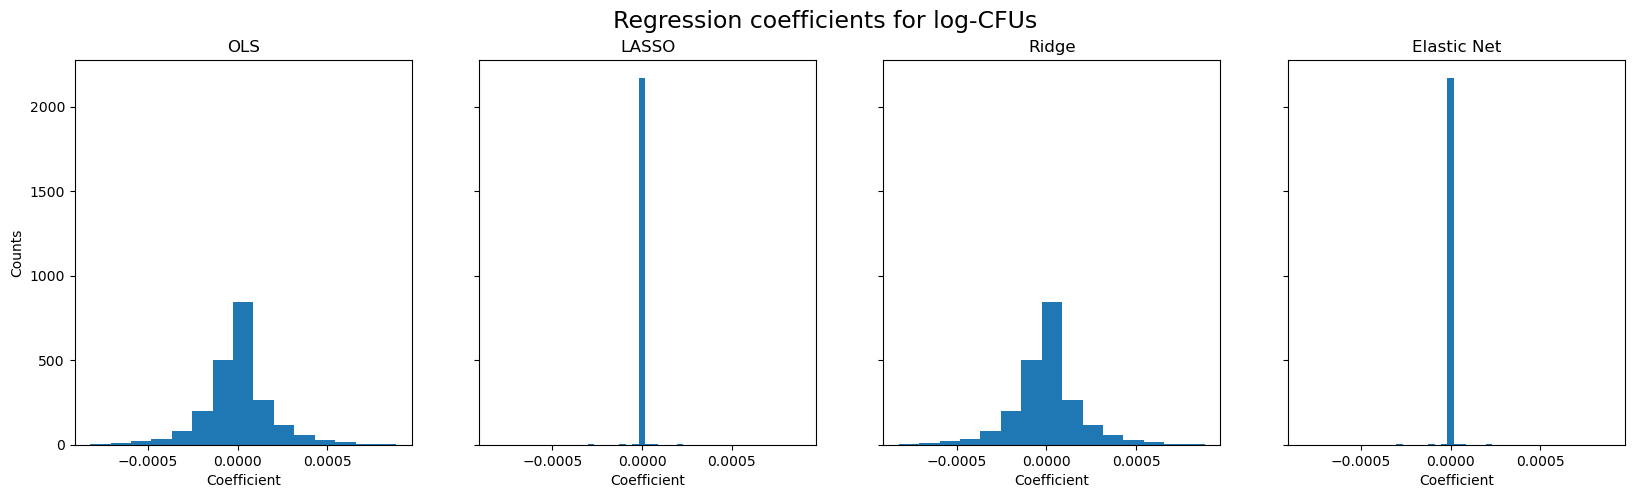

In [36]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5), sharey = True, sharex = True)

fig.suptitle("Regression coefficients for log-CFUs", fontsize = 17)

ax[0].hist(log_coefs["lm_coefs"], bins = 15)
ax[0].set_title("OLS")
ax[0].set_xlabel("Coefficient")
ax[0].set_ylabel("Counts")
ax[0].locator_params(axis = "x", nbins = 7)

ax[1].hist(log_coefs["lasso_coefs"], bins = 15)
ax[1].set_title("LASSO")
ax[1].set_xlabel("Coefficient")
ax[1].locator_params(axis = "x", nbins = 7)

ax[2].hist(log_coefs["ridge_coefs"], bins = 15)
ax[2].set_title("Ridge")
ax[2].set_xlabel("Coefficient")
ax[2].locator_params(axis = "x", nbins = 7)

ax[3].hist(log_coefs["en_coefs"], bins = 15)
ax[3].set_title("Elastic Net")
ax[3].set_xlabel("Coefficient")
ax[3].locator_params(axis = "x", nbins = 7)

Notice that almost all of the coefficients for LASSO and Elastic Net are 0. It seems like the L1 regularization is very aggressive on our data. Also, the OLS and Ridge regression coefficients have almost the same distribution, showing that L2 regularization is very weak on our data. 

Let's also try multiplying our coefficients by the standard deviations of each feature. This will give us an importance metric for each feature, since genes that vary very little across samples will have less contribution to the prediction.

$\text{importance}(x_j) = \beta_j * \text{std}(x_j)$

In [37]:
# Add columns of std * coefficient
log_coefs["lm_coefs(std)"] = log_coefs["lm_coefs"] * log_coefs["std"]
log_coefs["lasso_coefs(std)"] = log_coefs["lasso_coefs"] * log_coefs["std"]
log_coefs["ridge_coefs(std)"] = log_coefs["ridge_coefs"] * log_coefs["std"]
log_coefs["en_coefs(std)"] = log_coefs["en_coefs"] * log_coefs["std"]
log_coefs.head(n = 5)

,gene,lm_coefs,lasso_coefs,ridge_coefs,en_coefs,std,lm_coefs(std),lasso_coefs(std),ridge_coefs(std),en_coefs(std)
0,SP_0001,0.000168,0.0,0.000168,0.0,68.549852,0.011486,0.0,0.011486,0.0
1,SP_0002,-0.000038,0.0,-0.000038,0.0,55.831470,-0.002144,0.0,-0.002144,0.0
2,SP_0003,0.000320,0.0,0.000320,0.0,59.627499,0.019085,0.0,0.019084,0.0
3,SP_0004,-0.000190,0.0,-0.000190,0.0,168.386944,-0.031985,0.0,-0.031982,0.0
4,SP_0005,0.000033,0.0,0.000033,0.0,22.013842,0.000735,0.0,0.000735,0.0


Let's try plotting histograms of the importance metrics for each of the models.

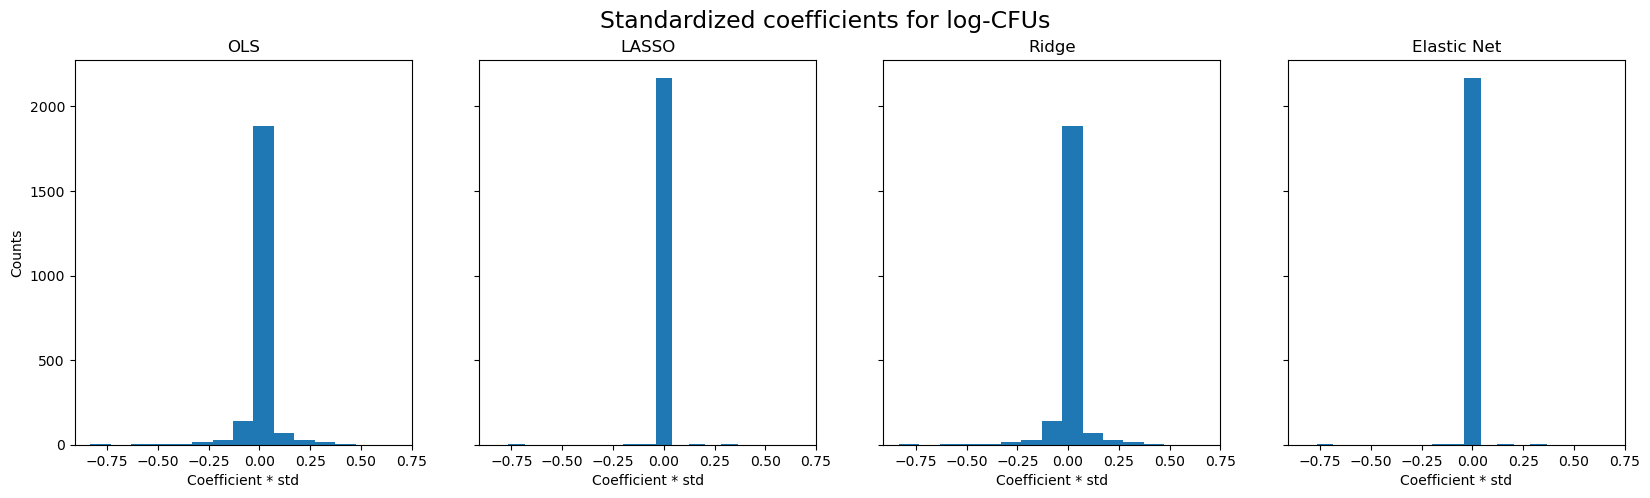

In [38]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5), sharey = True, sharex = True)

fig.suptitle("Standardized coefficients for log-CFUs", fontsize = 17)

ax[0].hist(log_coefs["lm_coefs(std)"], bins = 15)
ax[0].set_title("OLS")
ax[0].set_xlabel("Coefficient * std")
ax[0].set_ylabel("Counts")
ax[0].locator_params(axis = "x", nbins = 7)

ax[1].hist(log_coefs["lasso_coefs(std)"], bins = 15)
ax[1].set_title("LASSO")
ax[1].set_xlabel("Coefficient * std")
ax[1].locator_params(axis = "x", nbins = 7)

ax[2].hist(log_coefs["ridge_coefs(std)"], bins = 15)
ax[2].set_title("Ridge")
ax[2].set_xlabel("Coefficient * std")
ax[2].locator_params(axis = "x", nbins = 7)

ax[3].hist(log_coefs["en_coefs(std)"], bins = 15)
ax[3].set_title("Elastic Net")
ax[3].set_xlabel("Coefficient * std")
ax[3].locator_params(axis = "x", nbins = 7)

Okay, let's construct dataframes for each model, where we have gene names as the index and importance values (coeff * std) as our values. We can use these to find the top 30 features for each model and plot their std * coefficients.

C:\Users\eddyk\AppData\Local\Temp\ipykernel_19472\2140084311.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


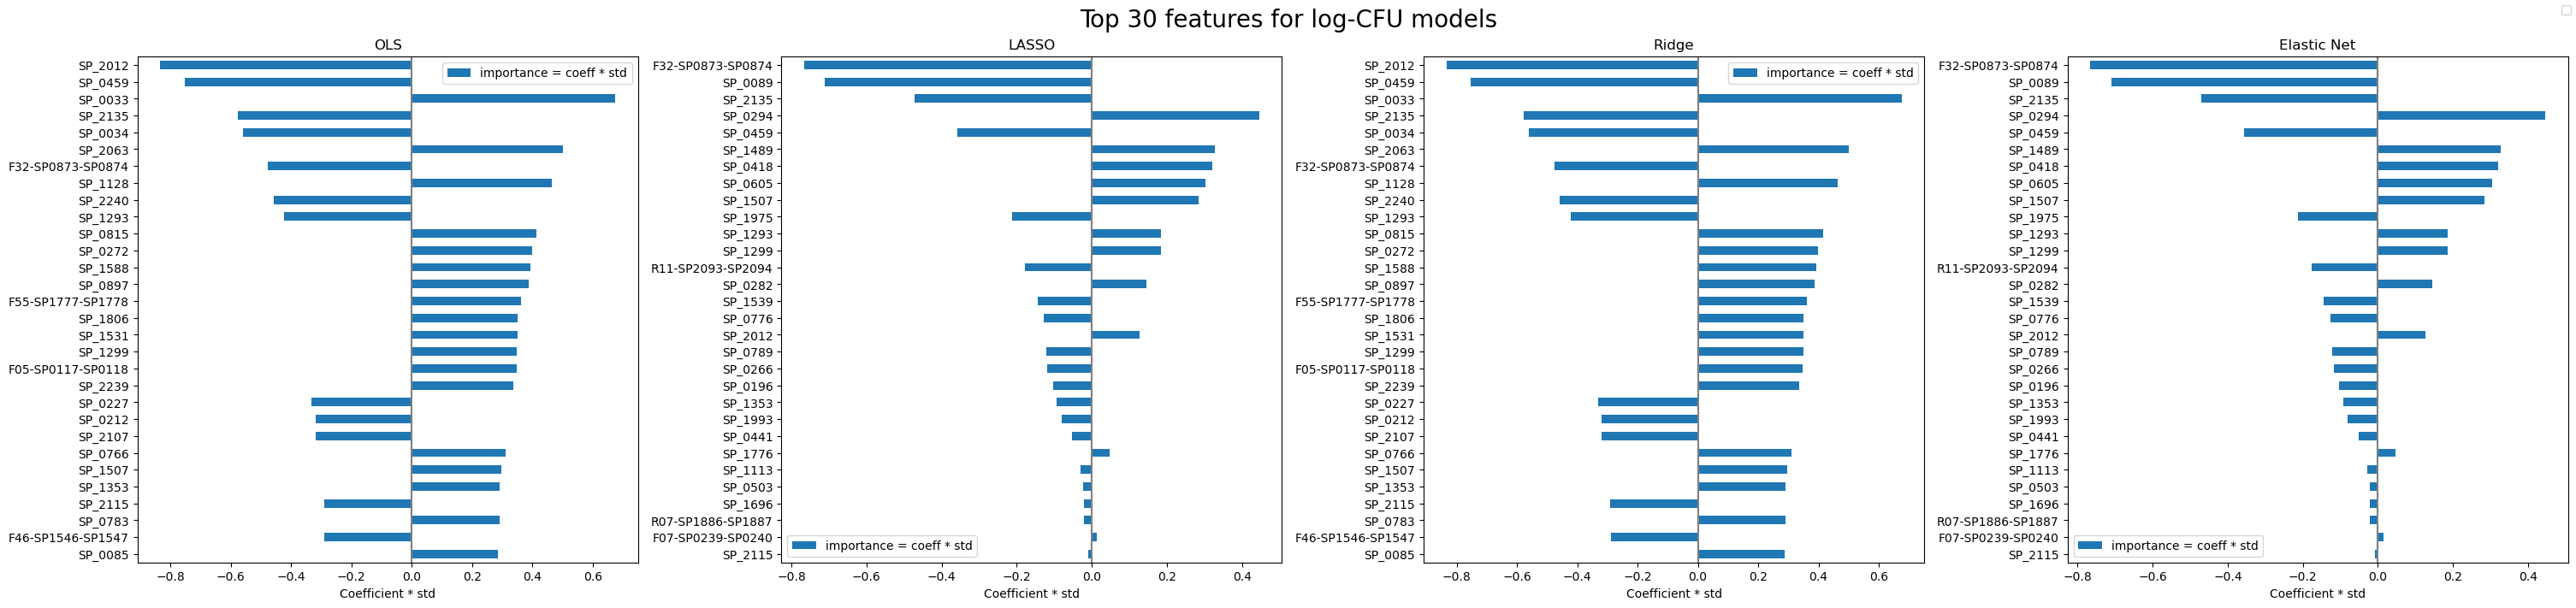

In [39]:
# Create df of OLS coefs
log_lm_df = pd.DataFrame(
    log_lm.coef_ * np.std(X_train_log, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Create df of lasso coefs
log_lasso_df = pd.DataFrame(
    log_lasso.coef_ * np.std(X_train_log, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Create df of ridge coefs
log_ridge_df = pd.DataFrame(
    log_ridge.coef_ * np.std(X_train_log, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Create df of elasticnet coefs
log_en_df = pd.DataFrame(
    log_en.coef_ * np.std(X_train_log, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Reorder coefs from greatest abs to least abs
log_lm_df    = log_lm_df.iloc[np.argsort(-np.abs(log_lm_df["importance = coeff * std"]))]
log_lasso_df = log_lasso_df.iloc[np.argsort(-np.abs(log_lasso_df["importance = coeff * std"]))]
log_ridge_df = log_ridge_df.iloc[np.argsort(-np.abs(log_ridge_df["importance = coeff * std"]))]
log_en_df    = log_en_df.iloc[np.argsort(-np.abs(log_en_df["importance = coeff * std"]))]

# Plot top 30 coefficients
fig, axes = plt.subplots(1, 4, figsize = (30, 7))
fig.set_constrained_layout(True)
fig.legend()
fig.suptitle("Top 30 features for log-CFU models", fontsize = 20)

# Plot
log_lm_df.iloc[:30].plot(kind = "barh", ax = axes[0]).invert_yaxis()
axes[0].set_title("OLS")
axes[0].set_xlabel("Coefficient * std")
axes[0].axvline(x = 0, color = ".5")

log_lasso_df.iloc[:30].plot(kind = "barh", ax = axes[1]).invert_yaxis()
axes[1].set_title("LASSO")
axes[1].set_xlabel("Coefficient * std")
axes[1].axvline(x = 0, color = ".5")


log_ridge_df.iloc[:30].plot(kind = "barh", ax = axes[2]).invert_yaxis()
axes[2].set_title("Ridge")
axes[2].set_xlabel("Coefficient * std")
axes[2].axvline(x = 0, color = ".5")


log_en_df.iloc[:30].plot(kind = "barh", ax = axes[3]).invert_yaxis()
axes[3].set_title("Elastic Net")
axes[3].set_xlabel("Coefficient * std")
axes[3].axvline(x = 0, color = ".5")

OLS and Ridge are essentially the same, and LASSO and ElasticNet are essentially the same. Let's move forward with just OLS and LASSO, since these have the lower RMSEs.

Let's load the gene annotation data, so that we see what genes have been found by our models.

In [42]:
# Gene data
annotations = pd.read_csv("C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/Annotation_TIGR4.tsv", sep = "\t")
annotations.set_index("TIGR4.old", inplace = True, drop = True)
print(annotations.shape)
print(annotations.columns)
annotations.head(n = 5)

(1800, 30)
Index(['Cluster', 'Subcluster', 'Product', 'Strain', 'Genome', 'locus',
       'Start', 'End', 'Strand', 'Total.Insertions', 'Total.Sites', 'zbar',
       'Binomial.Call', 'HMM.Call', 'D39.old', 'TAIWAN.19F.new',
       'TAIWAN.19F.old', 'D39.new', 'GENE.DESCRIPTION', 'GENE.CATEGORY',
       'Location.Tag', 'Tag1', 'Tag2', 'Tag3', 'Category1', 'Category2',
       'Category3', 'No..of.Categories', 'Gene.Name',
       'GO.terms..biological.process.'],
      dtype='str')


,Cluster,Subcluster,Product,Strain,Genome,locus,Start,End,Strand,Total.Insertions,...,Location.Tag,Tag1,Tag2,Tag3,Category1,Category2,Category3,No..of.Categories,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,,,,,,,,,,
n.p.,1,1_5,DUF3278 domain-containing protein,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,1,1_2,endonuclease/exonuclease/phosphatase family pr...,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,Membrane,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
SP_0828,2,2_0,ribose-5-phosphate isomerase RpiA,TIGR4-AC316,CP035239,EQH41_04105,777989,778673,1,5,...,Intracellular,METABOLISM,NaN,NaN,Carbohydrate metabolism,NaN,NaN,1.0,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,3,3_0,HU family DNA-binding protein,TIGR4-AC316,CP035239,EQH41_05540,1042358,1042634,1,0,...,Intracellular,GENETIC INFORMATION PROCESSING,NaN,NaN,Replication,NaN,NaN,1.0,NaN,chromosome condensation
SP_1925,4,4_0,hypothetical protein,TIGR4-AC316,CP035239,EQH41_09740,1826524,1827133,-1,16,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [43]:
# Gene data
annotations = annotations[["Product", "Tag1", "Tag2", "Tag3", "Category1", "Category2", "Category3", "Gene.Name", "GO.terms..biological.process."]]
annotations.head(n = 5)

,Product,Tag1,Tag2,Tag3,Category1,Category2,Category3,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,
n.p.,DUF3278 domain-containing protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,endonuclease/exonuclease/phosphatase family pr...,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0828,ribose-5-phosphate isomerase RpiA,METABOLISM,NaN,NaN,Carbohydrate metabolism,NaN,NaN,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,HU family DNA-binding protein,GENETIC INFORMATION PROCESSING,NaN,NaN,Replication,NaN,NaN,NaN,chromosome condensation
SP_1925,hypothetical protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's merge of the annotation dataframe to dataframes containing the top features we previously identified for OLS and LASSO.

In [44]:
# Left join top 30 coeffs and annotations, 
log_lm_df_annot = pd.merge(log_lm_df, annotations, how = "left", left_index = True, right_index = True)
log_lasso_df_annot = pd.merge(log_lasso_df, annotations, how = "left", left_index = True, right_index = True)

In [45]:
log_lm_df_annot

,importance = coeff * std,Product,Tag1,Tag2,Tag3,Category1,Category2,Category3,Gene.Name,GO.terms..biological.process.
SP_2012,-0.833768,type I glyceraldehyde-3-phosphate dehydrogenase,METABOLISM,NaN,NaN,Energy metabolism,NaN,NaN,gap,oxidation-reduction process // glycolytic proc...
SP_0459,-0.753691,formate C-acetyltransferase,METABOLISM,NaN,NaN,Carbohydrate metabolism,NaN,NaN,NaN,carbohydrate metabolic process
SP_0033,0.674850,CoA-binding protein,METABOLISM,NaN,NaN,Various metabolism,NaN,NaN,NaN,NaN
SP_2135,-0.577466,50S ribosomal protein L33,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,rpmG,translation
SP_0034,-0.560443,YeiH family putative sulfate export transporter,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
SP_1091,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_1028,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F51-SP2213-SP2214,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0195,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Okay, now we can plot the importances with the additional annotations, just for the OLS and LASSO models.

Text(0, 0.5, 'Gene product')

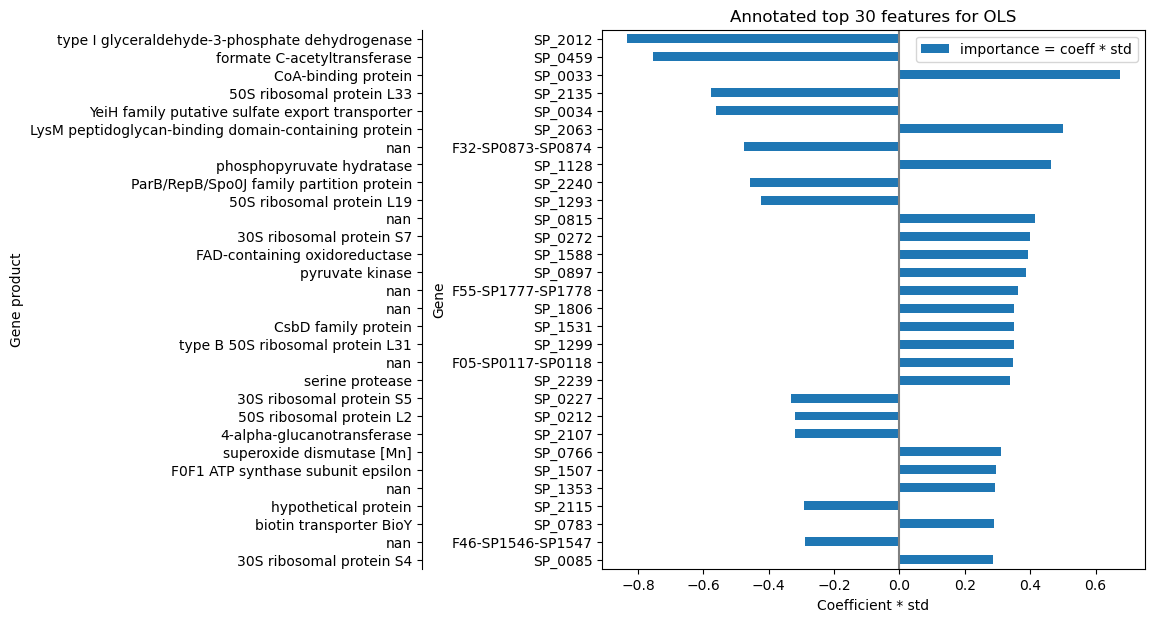

In [46]:
# OLS
fig, ax = plt.subplots(figsize = (7, 7))

# Barplot of coeffs
log_lm_df_annot.iloc[:30].plot(kind = "barh", ax = ax).invert_yaxis()


ax.set_title("Annotated top 30 features for OLS")
ax.set_xlabel("Coefficient * std")
ax.set_ylabel("Gene")
ax.axvline(x = 0, color = ".5")

secax = ax.secondary_yaxis("left")
secax.set_yticks(range(len(log_lm_df_annot.iloc[:30].index)))
secax.set_yticklabels(log_lm_df_annot.iloc[:30]["Product"])
secax.spines['left'].set_position(('outward', 130))
secax.set_ylabel("Gene product")


Text(0, 0.5, 'Gene product')

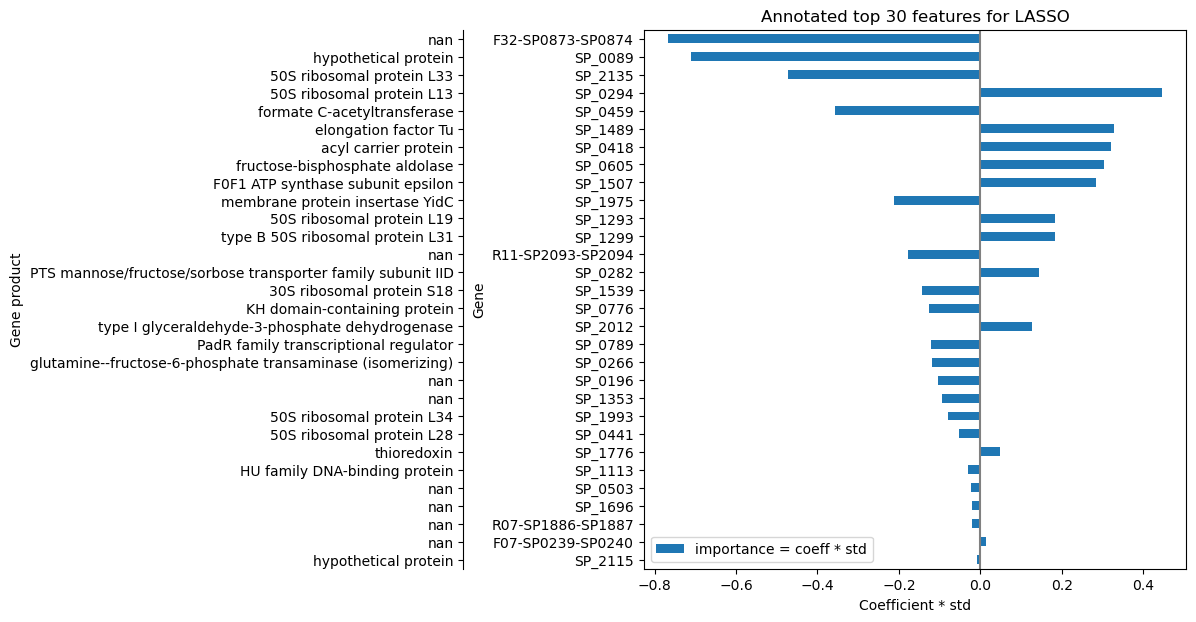

In [47]:
# LASSO
fig, ax = plt.subplots(figsize = (7, 7))

# Barplot of coeffs
log_lasso_df_annot.iloc[:30].plot(kind = "barh", ax = ax).invert_yaxis()


ax.set_title("Annotated top 30 features for LASSO")
ax.set_xlabel("Coefficient * std")
ax.set_ylabel("Gene")
ax.axvline(x = 0, color = ".5")

secax = ax.secondary_yaxis("left")
secax.set_yticks(range(len(log_lasso_df_annot.iloc[:30].index)))
secax.set_yticklabels(log_lasso_df_annot.iloc[:30]["Product"])
secax.spines['left'].set_position(('outward', 130))
secax.set_ylabel("Gene product")

## Feature Selection + Modeling

In [48]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV

### Variance Filtering

We started with RFE, but this takes far too long with 2000 features. Let's begin by using Variance thresholds instead to eliminate features that hardly vary across sample. We suspect there will be a lot of these for genes that have a low basal level of transcription. Let's begin by taking a look at how the variance varies across the features in the training data.

Minimum feature std    : 0.0
0.25 Quantile          : 14.717526428158276
0.50 Quantile (median) : 38.9799860875092
0.75 Quantile          : 108.11321098194244
Maximum feature std    : 16912.028884597283


Text(0, 0.5, 'Counts')

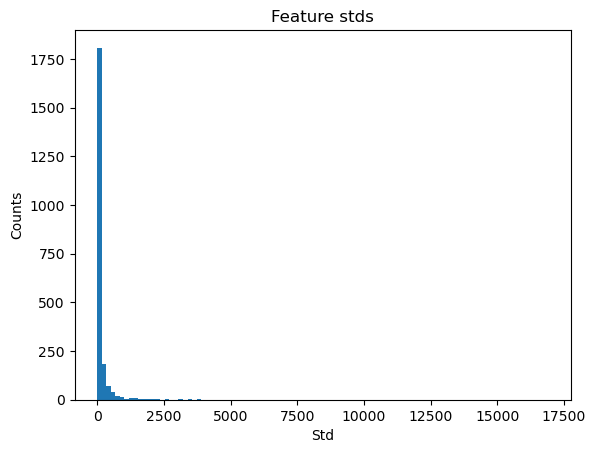

In [49]:
from sklearn.feature_selection import VarianceThreshold

# Store std across features
feature_std = np.std(X_train_log, axis = 0)

# Print summary statistics 
print(f"Minimum feature std    : {np.min(feature_std)}")
print(f"0.25 Quantile          : {np.quantile(feature_std, 0.25)}")
print(f"0.50 Quantile (median) : {np.median(feature_std)}")
print(f"0.75 Quantile          : {np.quantile(feature_std, 0.75)}")
print(f"Maximum feature std    : {np.max(feature_std)}")

# Plot
plt.hist(feature_std, bins = 100)
plt.title("Feature stds")
plt.xlabel("Std")
plt.ylabel("Counts")

In [50]:
feature_std

SP_0001     68.549852
SP_0002     55.831470
SP_0003     59.627499
SP_0004    168.386944
SP_0005     22.013842
              ...    
SP_2236     22.419353
SP_2237      9.828742
SP_2238     19.668241
SP_2239    519.736388
SP_2240    749.105798
Length: 2191, dtype: float64

Let's look at the insanely high std genes. Here's the top 10 stds

In [51]:
# Top 10 std
top10_std = feature_std.iloc[np.argsort(-feature_std)[:10]]
top10_std

SP_1299              16912.028885
SP_1993              15392.678539
SP_2135              10338.956720
SP_0441               8564.155934
SP_0789               7307.689325
SP_1414               7171.721746
SP_1293               6705.274125
SP_0838               5474.119767
F32-SP0873-SP0874     5375.946942
SP_0418               4795.356678
dtype: float64

Remove unannotated fragment.

In [52]:
top9_std = top10_std[top10_std.index != "F32-SP0873-SP0874"]
annotations.loc[top9_std.index]

,Product,Tag1,Tag2,Tag3,Category1,Category2,Category3,Gene.Name,GO.terms..biological.process.
SP_1299,type B 50S ribosomal protein L31,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,RpmE2,translation
SP_1993,50S ribosomal protein L34,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,rpmH,translation
SP_2135,50S ribosomal protein L33,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,rpmG,translation
SP_0441,50S ribosomal protein L28,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,rpmB,translation
SP_0789,PadR family transcriptional regulator,GENETIC INFORMATION PROCESSING,NaN,NaN,Transcription,NaN,NaN,NaN,NaN
SP_1414,30S ribosomal protein S21,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,RpsU,translation
SP_1293,50S ribosomal protein L19,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,RplS,translation
SP_0838,30S ribosomal protein S20,GENETIC INFORMATION PROCESSING,NaN,NaN,Translation,NaN,NaN,rpsT,NaN
SP_0418,acyl carrier protein,METABOLISM,NaN,NaN,Lipid metabolism,NaN,NaN,acpP,fatty acid biosynthetic process // fatty acid ...


Ribosomal proteins vary the most in our data! This makes sense in terms of translation, but this is likely what our model will pick up.

It seems like a reasonable cut-off to use just 25% of the features, since we do have so many features (2000). Let's try subsetting our data to these features.

In [53]:
# Grab indices of features with std > 
std_q75 = np.quantile(feature_std, 0.75)
std_indices = [i for i in range(len(feature_std)) if np.array(feature_std)[i] > std_q75]

# Subset training and test data
X_train_std = X_train_log.iloc[:, std_indices]
X_test_std  = X_test_log.iloc[:, std_indices]

# Check dimensions
print(f"Number of variance-filtered features          : {len(std_indices)}")
print(f"Dimensions of variance-filtered training data : {X_train_std.shape}")
print(f"Dimensions of variance-filtered test data     : {X_test_std.shape}")

Number of variance-filtered features          : 548
Dimensions of variance-filtered training data : (326, 548)
Dimensions of variance-filtered test data     : (144, 548)


Awesome! Let's try training different models on these variance-filtered features and see how they perform.

In [54]:
# Models
std_lm = linear_model.LinearRegression()
std_lasso = linear_model.LassoCV(cv = 5)
std_ridge = linear_model.RidgeCV(cv = 5)
std_en = linear_model.ElasticNetCV(cv = 5)
std_rf = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Train
std_lm.fit(X_train_std, y_train_log)
std_lasso.fit(X_train_std, y_train_log)
std_ridge.fit(X_train_std, y_train_log)
std_en.fit(X_train_std, y_train_log)
std_rf.fit(X_train_std, y_train_log)

# Predictions
std_lm_preds = std_lm.predict(X_test_std)
std_lasso_preds = std_lasso.predict(X_test_std)
std_ridge_preds = std_ridge.predict(X_test_std)
std_en_preds = std_en.predict(X_test_std)
std_rf_preds = std_rf.predict(X_test_std)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.602e-01, tolerance: 1.065e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.955e-01, tolerance: 1.080e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

Summarize variance-filtered models using eval metrics.

In [55]:
# Initialize table for eval metrics
table3 = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

# Store std models
std_models = [std_lm, std_lasso, std_ridge, std_en, std_rf]
std_preds = [std_lm_preds, std_lasso_preds, std_ridge_preds, std_en_preds, std_rf_preds]
std_model_names = ["Simple LR", "LASSO", "Ridge", "ElasticNet", "Random Forest"] 

# Add model eval metrics to table
for i in range(len(std_models)):
    table3.add_row([std_model_names[i],
                round(root_mean_squared_error(y_test_log, std_preds[i]), 3), 
                round(mean_absolute_error(y_test_log, std_preds[i]), 3),
                round(std_models[i].score(X_train_std, y_train_log), 3),
                round(std_models[i].score(X_test_std, y_test_log), 3)])
    
# Show
table3.title = "Eval metrics for variance-filtered models (548 features)"

# Compare to previous model
table2.title = "Eval metrics for raw models (2191 features)"

print(table3)
print(table2)

+----------------------------------------------------------+
| Eval metrics for variance-filtered models (548 features) |
+---------------+-------+-------+-------------+------------+
|     Model     |  RMSE |  MAE  | R^2 (Train) | R^2 (Test) |
+---------------+-------+-------+-------------+------------+
|   Simple LR   | 1.015 | 0.783 |     1.0     |    0.67    |
|     LASSO     | 0.701 | 0.531 |    0.894    |   0.842    |
|     Ridge     | 1.015 | 0.783 |     1.0     |    0.67    |
|   ElasticNet  | 0.701 | 0.531 |    0.894    |   0.842    |
| Random Forest | 0.995 | 0.675 |    0.986    |   0.683    |
+---------------+-------+-------+-------------+------------+
+----------------------------------------------------------+
|       Eval metrics for raw models (2191 features)        |
+---------------+-------+-------+-------------+------------+
|     Model     |  RMSE |  MAE  | R^2 (Train) | R^2 (Test) |
+---------------+-------+-------+-------------+------------+
|   Simple LR   | 0.852 

Performance is pretty similar even when we filter out low variance features. This makes sense especially for the models with regularization, because those coefficients are already getting shrunk.

Let's look at the model coefficients again as we did before and see if anything interesting has been found.

C:\Users\eddyk\AppData\Local\Temp\ipykernel_19472\2170439852.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


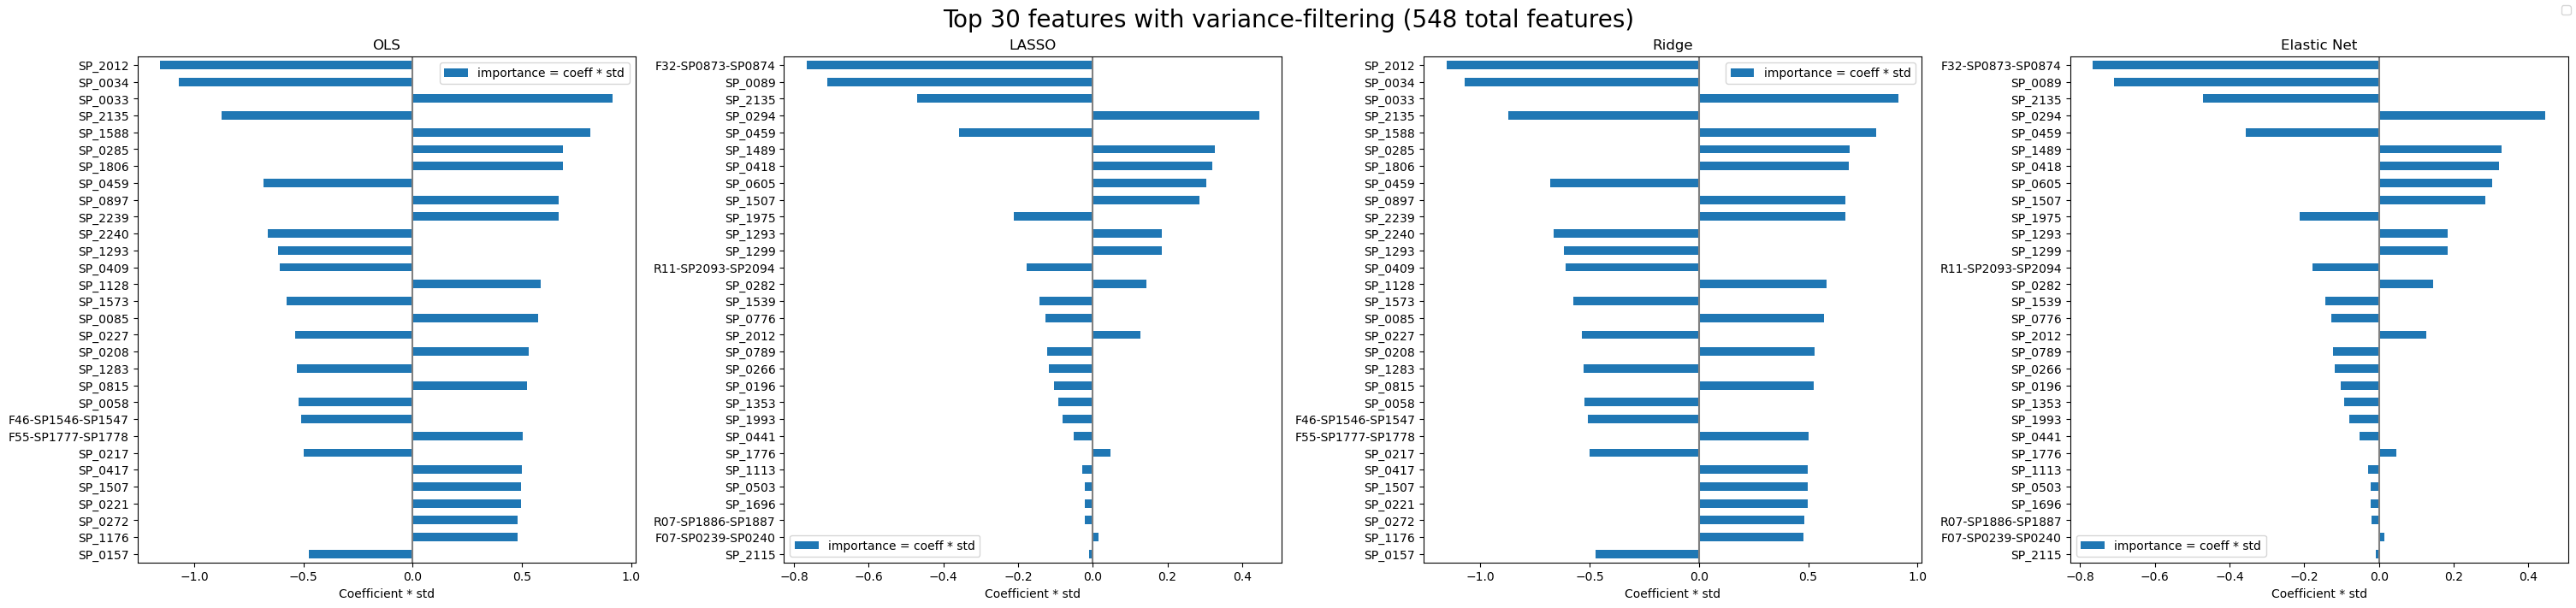

In [56]:
# OLS coefs
std_lm_df = pd.DataFrame(
    std_lm.coef_ * np.std(X_train_std, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# LASSO
std_lasso_df = pd.DataFrame(
    std_lasso.coef_ * np.std(X_train_std, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Ridge
std_ridge_df = pd.DataFrame(
    std_ridge.coef_ * np.std(X_train_std, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Create df of elasticnet coefs
std_en_df = pd.DataFrame(
    std_en.coef_ * np.std(X_train_std, axis = 0), # Calculate importance
    columns = ["importance = coeff * std"],
    index = genes
)

# Reorder coefs from greatest abs to least abs
std_lm_df    = std_lm_df.iloc[np.argsort(-np.abs(std_lm_df["importance = coeff * std"]))]
std_lasso_df = std_lasso_df.iloc[np.argsort(-np.abs(std_lasso_df["importance = coeff * std"]))]
std_ridge_df = std_ridge_df.iloc[np.argsort(-np.abs(std_ridge_df["importance = coeff * std"]))]
std_en_df    = std_en_df.iloc[np.argsort(-np.abs(std_en_df["importance = coeff * std"]))]

# Plot top 30 coefficients
fig, axes = plt.subplots(1, 4, figsize = (30, 7))
fig.set_constrained_layout(True)
fig.legend()
fig.suptitle("Top 30 features with variance-filtering (548 total features)", fontsize = 20)

# Plot
std_lm_df.iloc[:30].plot(kind = "barh", ax = axes[0]).invert_yaxis()
axes[0].set_title("OLS")
axes[0].set_xlabel("Coefficient * std")
axes[0].axvline(x = 0, color = ".5")

std_lasso_df.iloc[:30].plot(kind = "barh", ax = axes[1]).invert_yaxis()
axes[1].set_title("LASSO")
axes[1].set_xlabel("Coefficient * std")
axes[1].axvline(x = 0, color = ".5")

std_ridge_df.iloc[:30].plot(kind = "barh", ax = axes[2]).invert_yaxis()
axes[2].set_title("Ridge")
axes[2].set_xlabel("Coefficient * std")
axes[2].axvline(x = 0, color = ".5")

std_en_df.iloc[:30].plot(kind = "barh", ax = axes[3]).invert_yaxis()
axes[3].set_title("Elastic Net")
axes[3].set_xlabel("Coefficient * std")
axes[3].axvline(x = 0, color = ".5")

Plotting just OLS and ridge....

In [57]:
# Merge with annotations
std_lm_df_annot = pd.merge(std_lm_df, annotations, how = "left", left_index = True, right_index = True)
std_lasso_df_annot = pd.merge(std_lasso_df, annotations, how = "left", left_index = True, right_index = True)

Text(0, 0.5, 'Gene product')

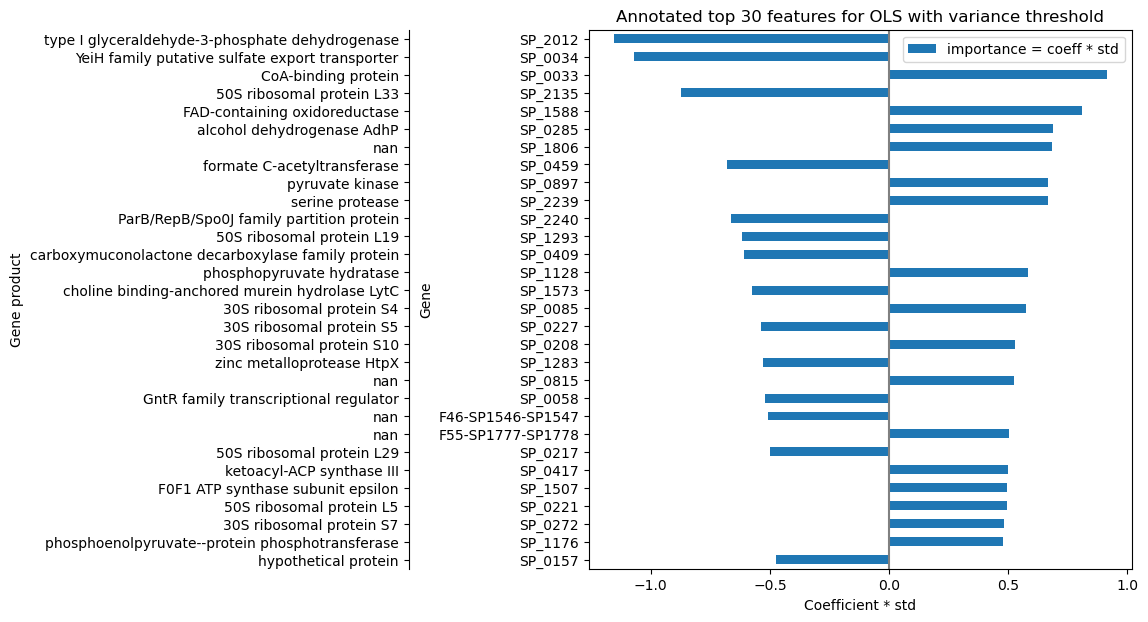

In [58]:
# OLS
fig, ax = plt.subplots(figsize = (7, 7))

# Barplot of coeffs
std_lm_df_annot.iloc[:30].plot(kind = "barh", ax = ax).invert_yaxis()

ax.set_title("Annotated top 30 features for OLS with variance threshold")
ax.set_xlabel("Coefficient * std")
ax.set_ylabel("Gene")
ax.axvline(x = 0, color = ".5")

secax = ax.secondary_yaxis("left")
secax.set_yticks(range(len(std_lm_df_annot.iloc[:30].index)))
secax.set_yticklabels(std_lm_df_annot.iloc[:30]["Product"])
secax.spines['left'].set_position(('outward', 130))
secax.set_ylabel("Gene product")

Text(0, 0.5, 'Gene product')

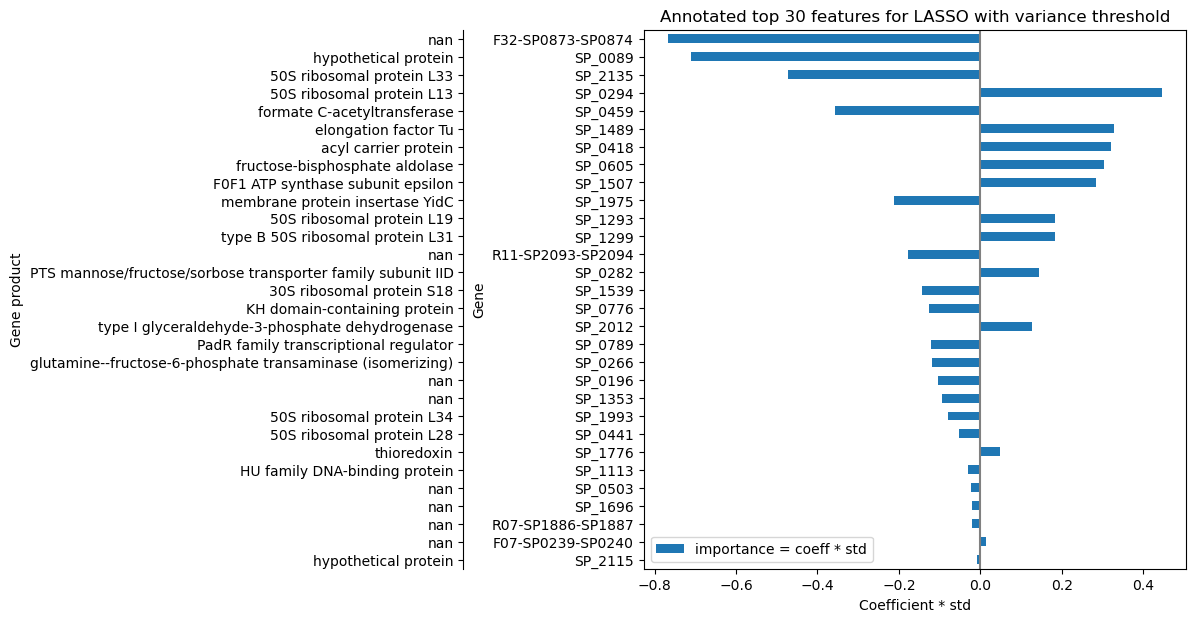

In [59]:
# LASSO
fig, ax = plt.subplots(figsize = (7, 7))

# Barplot of coeffs
std_lasso_df_annot.iloc[:30].plot(kind = "barh", ax = ax).invert_yaxis()


ax.set_title("Annotated top 30 features for LASSO with variance threshold")
ax.set_xlabel("Coefficient * std")
ax.set_ylabel("Gene")
ax.axvline(x = 0, color = ".5")

secax = ax.secondary_yaxis("left")
secax.set_yticks(range(len(std_lasso_df_annot.iloc[:30].index)))
secax.set_yticklabels(std_lasso_df_annot.iloc[:30]["Product"])
secax.spines['left'].set_position(('outward', 130))
secax.set_ylabel("Gene product")

### Tree-based

Let's fit a tree-based regression model to define feature importance.

In [60]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectFromModel

# Fit ExtraTrees Regressor to select top features
clf = ExtraTreesRegressor(n_estimators = 100, random_state = 111)
clf = clf.fit(X_train_log, y_train_log)

Let's select the top features and subset our training data to those features.

In [61]:
# Define selector to select top features from extratrees regressor
selector = SelectFromModel(clf, prefit = True)

# Keep data as df
selector.set_output(transform = "pandas")

# Subset data to appropriate features
X_train_tree = selector.transform(X_train_log)
X_test_tree = selector.transform(X_test_log)

# Check dims
print(f"ExtraTrees Regressor selected {X_train_tree.shape[1]} features")

ExtraTrees Regressor selected 199 features


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Okay, now we'll test out our previous models on our selected top features!

In [62]:
# Models
tree_lm = linear_model.LinearRegression()
tree_lasso = linear_model.LassoCV(cv = 5)
tree_ridge = linear_model.RidgeCV(cv = 5)
tree_en = linear_model.ElasticNetCV(cv = 5)
tree_rf = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Train
tree_lm.fit(X_train_tree, y_train_log)
tree_lasso.fit(X_train_tree, y_train_log)
tree_ridge.fit(X_train_tree, y_train_log)
tree_en.fit(X_train_tree, y_train_log)
tree_rf.fit(X_train_tree, y_train_log)

# Predictions
tree_lm_preds = tree_lm.predict(X_test_tree)
tree_lasso_preds = tree_lasso.predict(X_test_tree)
tree_ridge_preds = tree_ridge.predict(X_test_tree)
tree_en_preds = tree_en.predict(X_test_tree)
tree_rf_preds = tree_rf.predict(X_test_tree)

Evaluations.

In [63]:
# Initialize table for eval metrics
table4 = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

# Store std models
tree_models = [tree_lm, tree_lasso, tree_ridge, tree_en, tree_rf]
tree_preds = [tree_lm_preds, std_lasso_preds, tree_ridge_preds, tree_en_preds, tree_rf_preds]
tree_model_names = ["Simple LR", "LASSO", "Ridge", "ElasticNet", "Random Forest"] 

# Add model eval metrics to table
for i in range(len(tree_models)):
    table4.add_row([tree_model_names[i],
                round(root_mean_squared_error(y_test_log, tree_preds[i]), 3), 
                round(mean_absolute_error(y_test_log, tree_preds[i]), 3),
                round(tree_models[i].score(X_train_tree, y_train_log), 3),
                round(tree_models[i].score(X_test_tree, y_test_log), 3)])
    
# Show
table4.title = "Eval metrics for tree-filtered models (199 features)"

print(table2, table3, table4)

+----------------------------------------------------------+
|       Eval metrics for raw models (2191 features)        |
+---------------+-------+-------+-------------+------------+
|     Model     |  RMSE |  MAE  | R^2 (Train) | R^2 (Test) |
+---------------+-------+-------+-------------+------------+
|   Simple LR   | 0.852 | 0.649 |     1.0     |   0.767    |
|     LASSO     | 0.701 | 0.531 |    0.894    |   0.842    |
|     Ridge     |   1   | 0.649 |     1.0     |   0.767    |
|   ElasticNet  |   1   | 0.531 |    0.894    |   0.842    |
| Random Forest |   1   | 0.678 |    0.985    |   0.681    |
+---------------+-------+-------+-------------+------------+ +----------------------------------------------------------+
| Eval metrics for variance-filtered models (548 features) |
+---------------+-------+-------+-------------+------------+
|     Model     |  RMSE |  MAE  | R^2 (Train) | R^2 (Test) |
+---------------+-------+-------+-------------+------------+
|   Simple LR   | 1.015 